<a href="https://colab.research.google.com/github/sasya025/Travclan_A2/blob/main/SECTION_2_CODE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("hotel_bookings (1).csv", keep_default_na=False)

print(df.shape)
print(df.columns)

(12000, 28)
Index(['booking_id', 'customer_id', 'customer_name', 'customer_segment',
       'customer_signup_date', 'customer_home_city', 'customer_loyalty_tier',
       'property_id', 'property_name', 'property_city', 'property_star_rating',
       'property_type', 'property_total_rooms', 'booking_date', 'checkin_date',
       'checkout_date', 'room_type', 'num_rooms', 'nights', 'booking_channel',
       'adr', 'discount_amount', 'coupon_code', 'total_amount',
       'payment_method', 'booking_status', 'review_rating', 'review_date'],
      dtype='object')


In [ ]:
completed = df[df['booking_status'] == 'Completed'].copy()

In [ ]:
channel_discount = (
    completed
    .groupby('booking_channel')
    .agg({
        'discount_amount':'sum',
        'total_amount':'sum'
    })
)

channel_discount['gross_revenue'] = (
    channel_discount['discount_amount']
    + channel_discount['total_amount']
)

channel_discount['discount_intensity'] = (
    channel_discount['discount_amount']
    / channel_discount['gross_revenue']
) * 100

channel_discount = (
    channel_discount
    .sort_values('discount_intensity', ascending=False)
)

print(channel_discount)

                  discount_amount  total_amount  gross_revenue  \
booking_channel                                                  
OTA                    7809779.10   99107449.63   1.069172e+08   
Travel Agent           2803263.89   60764166.35   6.356743e+07   
Direct Website         2520293.24   54863426.91   5.738372e+07   
Corporate Portal       3461545.37   80124748.72   8.358629e+07   

                  discount_intensity  
booking_channel                       
OTA                         7.304509  
Travel Agent                4.409906  
Direct Website              4.392000  
Corporate Portal            4.141283  


In [ ]:
platform_intensity = (
    completed['discount_amount'].sum()
    /
    (
        completed['discount_amount'].sum()
        +
        completed['total_amount'].sum()
    )
) * 100

print(platform_intensity)

5.328185134923569


In [ ]:
highest_channel = channel_discount.index[0]

highest_intensity = channel_discount.iloc[0]['discount_intensity']

gap = highest_intensity - platform_intensity

print(highest_channel)
print(highest_intensity)
print(gap)

OTA
7.30450947220319
1.976324337279621


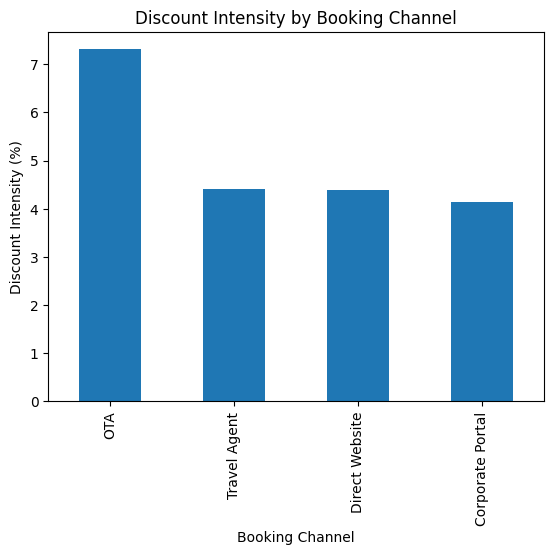

In [ ]:
import matplotlib.pyplot as plt

channel_discount['discount_intensity'].plot(
    kind='bar'
)

plt.title('Discount Intensity by Booking Channel')
plt.ylabel('Discount Intensity (%)')
plt.xlabel('Booking Channel')
plt.show()

In [ ]:
platform_segment = (
    df['customer_segment']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

ota_segment = (
    df[df['booking_channel']=='OTA']
    ['customer_segment']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

segment_mix = pd.concat(
    [platform_segment, ota_segment],
    axis=1
)

segment_mix.columns = [
    'Platform %',
    'OTA %'
]

print(segment_mix)

                  Platform %  OTA %
customer_segment                   
Individual             64.17  72.25
Corporate              24.10  14.06
Group                  11.73  13.69


In [ ]:
platform_tier = (
    df['customer_loyalty_tier']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

ota_tier = (
    df[df['booking_channel']=='OTA']
    ['customer_loyalty_tier']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

tier_mix = pd.concat(
    [platform_tier, ota_tier],
    axis=1
)

tier_mix.columns = [
    'Platform %',
    'OTA %'
]

print(tier_mix)

                       Platform %  OTA %
customer_loyalty_tier                   
None                        46.42  44.17
Silver                      26.12  26.76
Gold                        17.50  18.99
Platinum                     9.95  10.08


In [ ]:
platform_city = (
    df['customer_home_city']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

ota_city = (
    df[df['booking_channel']=='OTA']
    ['customer_home_city']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

city_mix = pd.concat(
    [platform_city, ota_city],
    axis=1
)

city_mix.columns = ['Platform %', 'OTA %']

print(city_mix.head(10))

                    Platform %  OTA %
customer_home_city                   
Chennai                  12.02  12.01
Delhi                    11.95  11.40
Manali                   11.88  11.92
Bangalore                11.26  12.08
Goa                       9.42   9.82
Jaipur                    9.06   8.24
Pune                      8.86   9.12
Udaipur                   8.64   8.55
Kochi                     8.57   8.95
Mumbai                    8.35   7.89


In [ ]:
ota = df[df['booking_channel'] == 'OTA'].copy()

ota['coupon_flag'] = ota['coupon_code'].apply(
    lambda x: 'Coupon'
    if x not in ['NONE', '']
    else 'No Coupon'
)

ota['coupon_flag'].value_counts()

,count
coupon_flag,
No Coupon,2810
Coupon,1435


In [ ]:
cancel_rate = (
    ota.groupby('coupon_flag')['booking_status']
       .apply(lambda x: (x == 'Cancelled').mean() * 100)
       .round(2)
)

print(cancel_rate)

coupon_flag
Coupon       21.67
No Coupon    22.28
Name: booking_status, dtype: float64


In [ ]:
ota_valid = ota[ota['num_rooms'] > 0].copy()

ota_valid['per_room_amount'] = (
    ota_valid['total_amount']
    / ota_valid['num_rooms']
)

per_room = (
    ota_valid.groupby('coupon_flag')
             ['per_room_amount']
             .mean()
             .round(2)
)

print(per_room)

coupon_flag
Coupon       19016.76
No Coupon    23023.94
Name: per_room_amount, dtype: float64


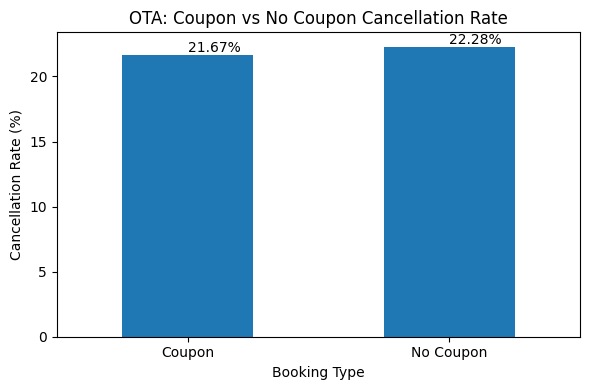

In [ ]:
import matplotlib.pyplot as plt

cancel_rate.plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('OTA: Coupon vs No Coupon Cancellation Rate')
plt.ylabel('Cancellation Rate (%)')
plt.xlabel('Booking Type')
plt.xticks(rotation=0)

for i, value in enumerate(cancel_rate):
    plt.text(i, value + 0.2, f'{value:.2f}%')

plt.tight_layout()
plt.show()

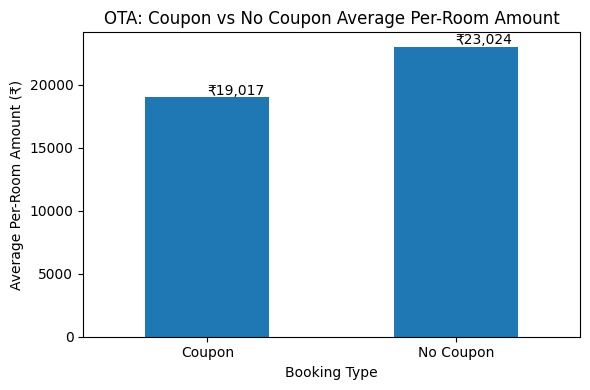

In [ ]:
import matplotlib.pyplot as plt

per_room.plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('OTA: Coupon vs No Coupon Average Per-Room Amount')
plt.ylabel('Average Per-Room Amount (₹)')
plt.xlabel('Booking Type')
plt.xticks(rotation=0)

for i, value in enumerate(per_room):
    plt.text(i, value + 200, f'₹{value:,.0f}')

plt.tight_layout()
plt.show()

In [ ]:
ota_completed = df[
    (df['booking_channel'] == 'OTA') &
    (df['booking_status'] == 'Completed')
]

ota_discount_spend = ota_completed['discount_amount'].sum()

print("OTA Discount Spend:", ota_discount_spend)

OTA Discount Spend: 7809779.1


In [ ]:
ota_gross_revenue = (
    ota_completed['total_amount'].sum()
    + ota_completed['discount_amount'].sum()
)

recoverable_margin = ota_gross_revenue * (
    (7.304509 - 5.328185) / 100
)

print("OTA Gross Revenue:", round(ota_gross_revenue,2))
print("Estimated Recoverable Margin:", round(recoverable_margin,2))

OTA Gross Revenue: 106917228.73
Estimated Recoverable Margin: 2113030.85
